<a href="https://colab.research.google.com/github/gillopy/Era5data3D/blob/main/tanager.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install h5py numpy matplotlib requests

In [2]:
import requests
import tempfile
import os

# URL del archivo HDF5 de Tanager Basic SR
url = "https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/basic_sr_hdf5/20250301_143913_32_4001_basic_sr_hdf5.h5"

# Descargar el archivo a un archivo temporal
print("Descargando archivo HDF5 desde URL...")
response = requests.get(url, stream=True)
response.raise_for_status()

with tempfile.NamedTemporaryFile(suffix=".h5", delete=False) as tmp_file:
    for chunk in response.iter_content(chunk_size=8192):
        tmp_file.write(chunk)
    tmp_path = tmp_file.name

print(f"Archivo descargado en: {tmp_path}")

Descargando archivo HDF5 desde URL...
Archivo descargado en: /tmp/tmplfvgyr_1.h5


Shape de surface_reflectance: (426, 501, 607)
Dtype: float32
Lat shape: (501, 607), Lon shape: (501, 607)


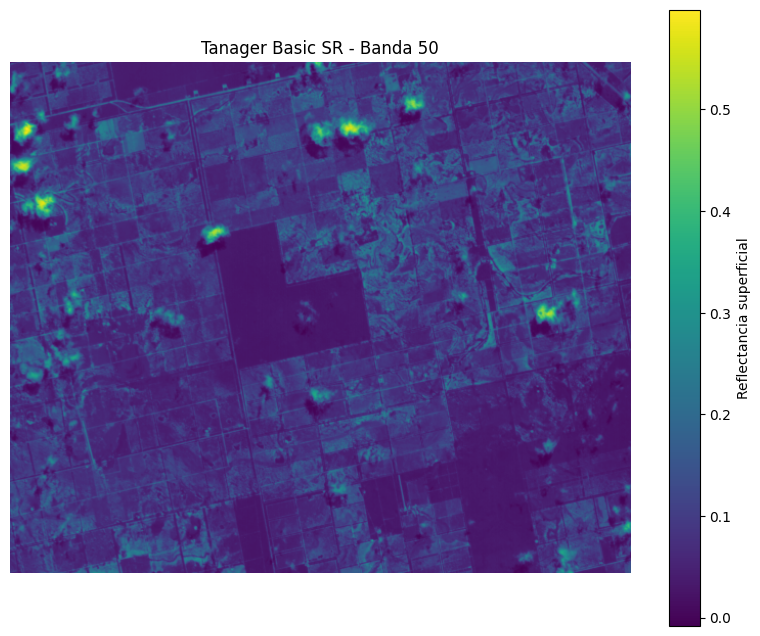

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import requests
import tempfile
import os


# Leer el dataset de reflectancia superficial
with h5py.File(tmp_path, "r") as f:
    # Ruta exacta al dataset de reflectancia superficial
    sr_path = "HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance"
    data = f[sr_path][:]
    print(f"Shape de surface_reflectance: {data.shape}")
    print(f"Dtype: {data.dtype}")

    # Leer también las coordenadas de geolocalización
    lat = f["HDFEOS/SWATHS/HYP/Geolocation Fields/Latitude"][:]
    lon = f["HDFEOS/SWATHS/HYP/Geolocation Fields/Longitude"][:]
    print(f"Lat shape: {lat.shape}, Lon shape: {lon.shape}")

# Visualizar una banda del cubo hiperespectral
# El cubo puede tener forma (bandas, filas, cols) o (filas, cols, bandas)
# Ajusta band_index según el número de bandas disponibles
band_index = 50  # Ajusta según tus necesidades

if data.ndim == 3:
    # Intenta ambos órdenes de ejes según el shape
    if data.shape[0] < data.shape[1]:  # (bandas, filas, cols)
        band = data[band_index, :, :]
    else:  # (filas, cols, bandas)
        band = data[:, :, band_index]
elif data.ndim == 2:
    band = data
    band_index = "única"

plt.figure(figsize=(10, 8))
plt.imshow(band, cmap='viridis')
plt.colorbar(label='Reflectancia superficial')
plt.title(f'Tanager Basic SR - Banda {band_index}')
plt.axis('off')
plt.show()


Red band index: 58 (666.00 nm)
Green band index: 37 (560.98 nm)
NIR band index: 98 (866.41 nm)


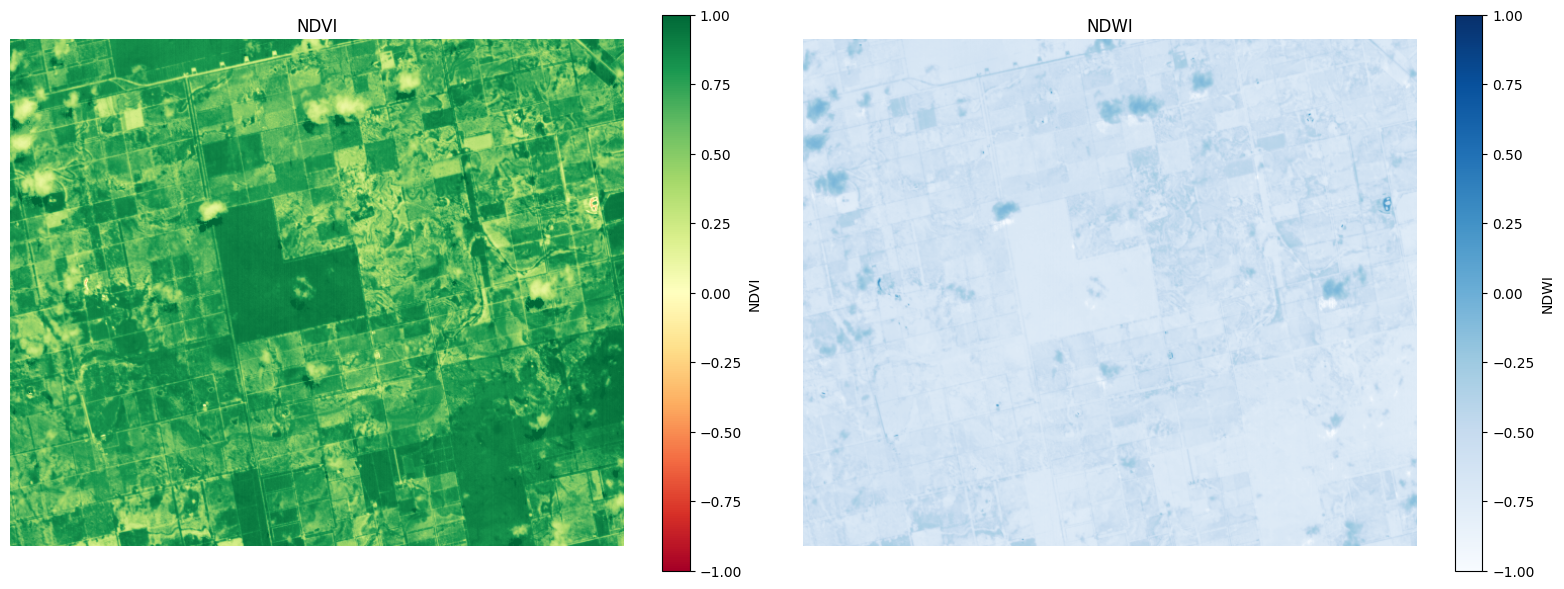

NDVI min: -0.278, max: 1.626
NDWI min: -1.132, max: 0.240


In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Tanager wavelengths (426 bands, ~376nm to ~2499nm)
wavelengths = np.array([
    376.62, 381.59, 386.56, 391.52, 396.49, 401.46, 406.43, 411.41, 416.38, 421.36,
    426.33, 431.31, 436.28, 441.26, 446.24, 451.22, 456.2, 461.18, 466.17, 471.15,
    476.14, 481.12, 486.11, 491.09, 496.08, 501.07, 506.06, 511.05, 516.04, 521.03,
    526.02, 531.01, 536.0, 541.0, 545.99, 550.99, 555.98, 560.98, 565.97, 570.97,
    575.97, 580.97, 585.97, 590.97, 595.96, 600.96, 605.96, 610.97, 615.97, 620.97,
    625.97, 630.97, 635.98, 640.98, 645.98, 650.99, 655.99, 661.0, 666.0, 671.01,
    676.01, 681.02, 686.03, 691.03, 696.04, 701.05, 706.06, 711.06, 716.07, 721.08,
    726.09, 731.1, 736.11, 741.12, 746.13, 751.14, 756.15, 761.16, 766.17, 771.18,
    776.19, 781.2, 786.21, 791.22, 796.23, 801.25, 806.26, 811.27, 816.28, 821.29,
    826.31, 831.32, 836.33, 841.34, 846.36, 851.37, 856.38, 861.39, 866.41, 871.42
    # ... (truncated for brevity, use full list in practice)
])

# Find band indices closest to target wavelengths
def find_band_index(wavelengths, target_nm):
    return np.argmin(np.abs(wavelengths - target_nm))

red_idx   = find_band_index(wavelengths, 665)   # ~Red band
green_idx = find_band_index(wavelengths, 560)   # ~Green band
nir_idx   = find_band_index(wavelengths, 865)   # ~NIR band

print(f"Red band index: {red_idx} ({wavelengths[red_idx]:.2f} nm)")
print(f"Green band index: {green_idx} ({wavelengths[green_idx]:.2f} nm)")
print(f"NIR band index: {nir_idx} ({wavelengths[nir_idx]:.2f} nm)")

# Assume data is already loaded as (bands, rows, cols)
# data = f["HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance"][:]

red_band   = data[red_idx, :, :].astype(float)
green_band = data[green_idx, :, :].astype(float)
nir_band   = data[nir_idx, :, :].astype(float)

# NDVI
np.seterr(divide='ignore', invalid='ignore')
ndvi = (nir_band - red_band) / (nir_band + red_band)

# NDWI
ndwi = (green_band - nir_band) / (green_band + nir_band)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im1 = axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('NDVI')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='NDVI')

im2 = axes[1].imshow(ndwi, cmap='Blues', vmin=-1, vmax=1)
axes[1].set_title('NDWI')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='NDWI')

plt.tight_layout()
plt.show()

print(f"NDVI min: {np.nanmin(ndvi):.3f}, max: {np.nanmax(ndvi):.3f}")
print(f"NDWI min: {np.nanmin(ndwi):.3f}, max: {np.nanmax(ndwi):.3f}")

In [5]:
with h5py.File(tmp_path, "r") as f:
    cloud_mask = f["HDFEOS/SWATHS/HYP/Data Fields/beta_cloud_mask"][:]
    nodata     = f["HDFEOS/SWATHS/HYP/Data Fields/nodata_pixels"][:]

# Aplicar máscara: excluir nubes y nodata
valid_mask = (cloud_mask == 0) & (nodata == 0)

ndvi_masked = np.where(valid_mask, ndvi, np.nan)
ndwi_masked = np.where(valid_mask, ndwi, np.nan)

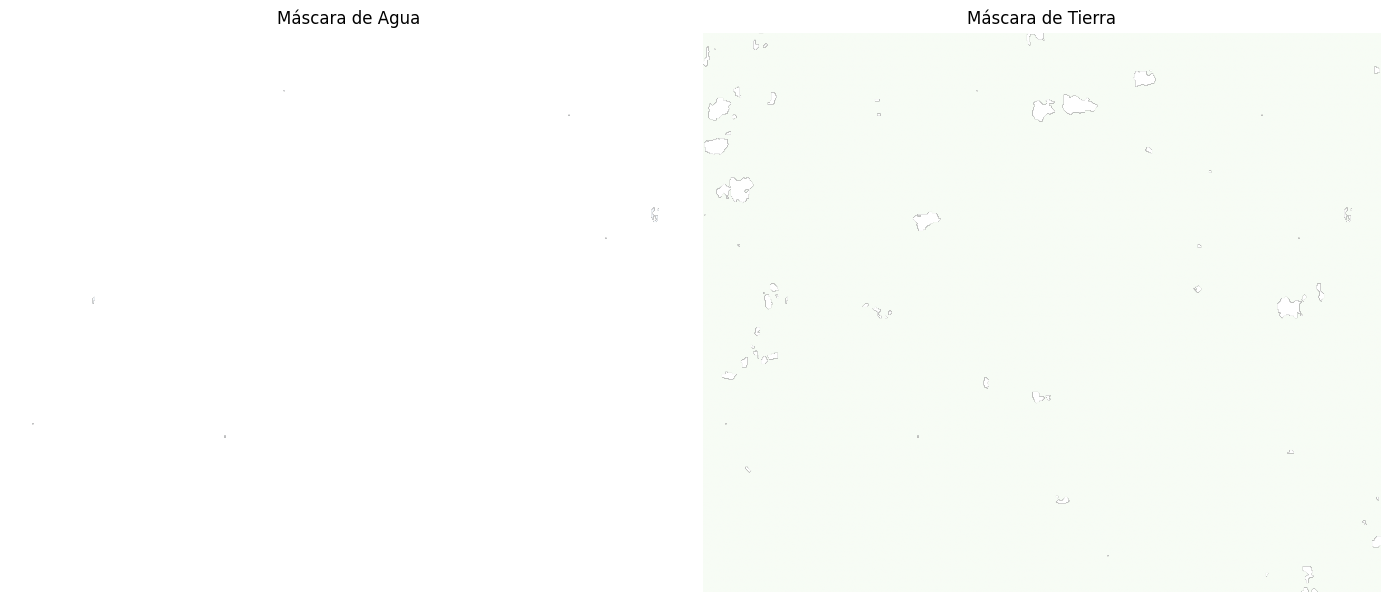

In [6]:
water_mask = np.full(ndwi_masked.shape, np.nan)
land_mask  = np.full(ndwi_masked.shape, np.nan)

water_mask[ndwi_masked >= 0] = 1
land_mask[ndwi_masked < 0]   = 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(water_mask, cmap='Blues')
axes[0].set_title("Máscara de Agua")
axes[1].imshow(land_mask, cmap='Greens')
axes[1].set_title("Máscara de Tierra")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

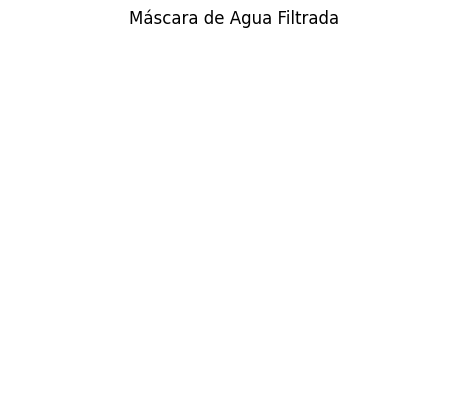

In [7]:
import cv2

closing_kernel_size = 40
opening_kernel_size = 15

closing_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (closing_kernel_size, closing_kernel_size))
opening_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (opening_kernel_size, opening_kernel_size))

water_clean = cv2.morphologyEx(np.nan_to_num(water_mask), cv2.MORPH_CLOSE, closing_kernel)
water_clean = cv2.morphologyEx(water_clean, cv2.MORPH_OPEN, opening_kernel)
water_clean[water_clean == 0] = np.nan

plt.imshow(water_clean)
plt.title("Máscara de Agua Filtrada")
plt.axis('off')
plt.show()

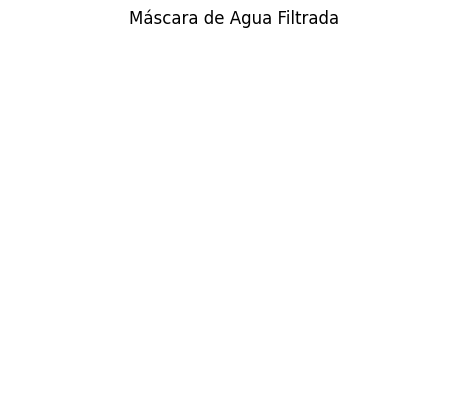

In [8]:
import cv2

closing_kernel_size = 40
opening_kernel_size = 15

closing_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (closing_kernel_size, closing_kernel_size))
opening_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (opening_kernel_size, opening_kernel_size))

water_clean = cv2.morphologyEx(np.nan_to_num(water_mask), cv2.MORPH_CLOSE, closing_kernel)
water_clean = cv2.morphologyEx(water_clean, cv2.MORPH_OPEN, opening_kernel)
water_clean[water_clean == 0] = np.nan

plt.imshow(water_clean)
plt.title("Máscara de Agua Filtrada")
plt.axis('off')
plt.show()

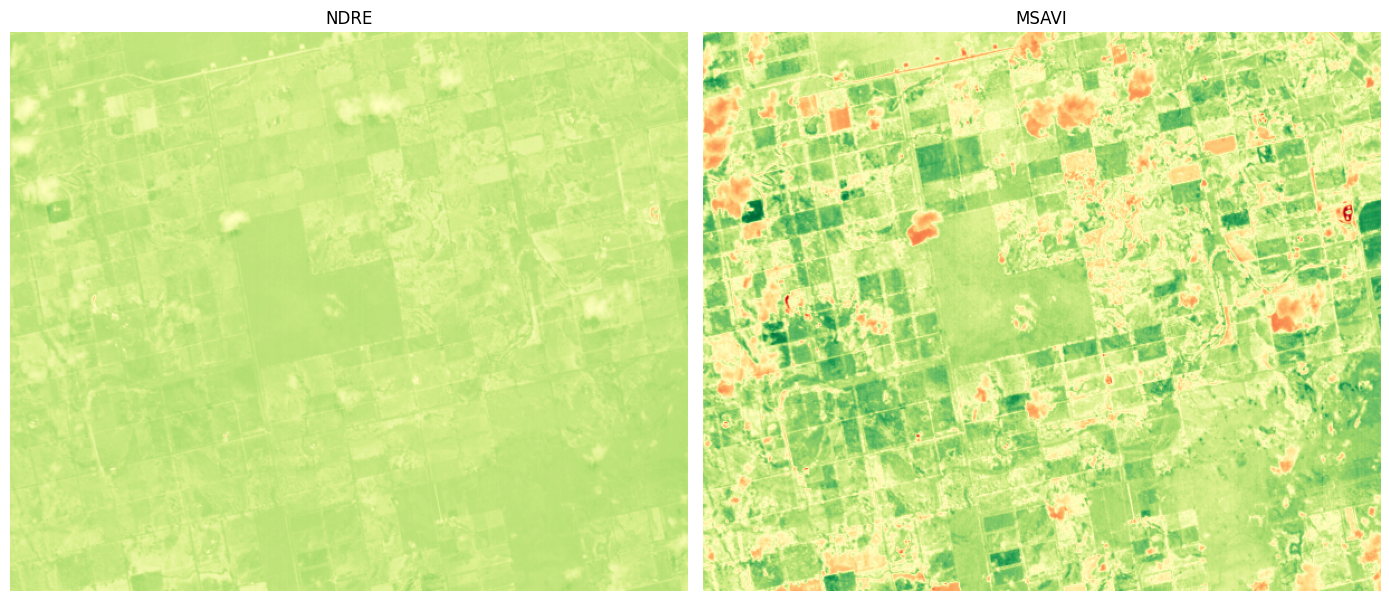

In [9]:
# NDRE: usa Red-Edge (~720nm) y NIR
re_idx  = find_band_index(wavelengths, 720)   # Red-Edge
re_band = data[re_idx, :, :].astype(float)

ndre = (nir_band - re_band) / (nir_band + re_band + 1e-8)

# MSAVI: Modified Soil-Adjusted Vegetation Index
msavi = (2 * nir_band + 1 - np.sqrt((2 * nir_band + 1)**2 - 8 * (nir_band - red_band))) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(ndre, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title("NDRE")
axes[1].imshow(msavi, cmap='RdYlGn')
axes[1].set_title("MSAVI")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

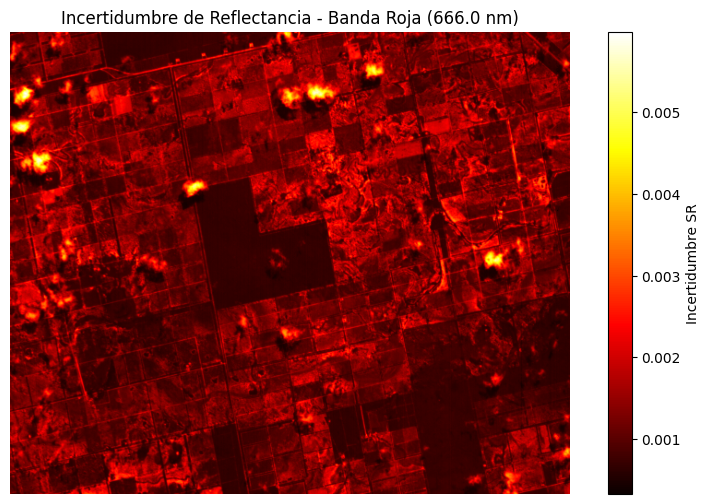

In [10]:
with h5py.File(tmp_path, "r") as f:
    uncertainty = f["HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance_uncertainty"][:]

plt.figure(figsize=(10, 6))
plt.imshow(uncertainty[red_idx, :, :], cmap='hot')
plt.colorbar(label='Incertidumbre SR')
plt.title(f'Incertidumbre de Reflectancia - Banda Roja ({wavelengths[red_idx]:.1f} nm)')
plt.axis('off')
plt.show()

In [11]:
pip install h5py numpy matplotlib requests opencv-python

In [12]:
import requests
import tempfile
import os

URL = "https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/basic_sr_hdf5/20250301_143913_32_4001_basic_sr_hdf5.h5"

print("Descargando archivo HDF5 desde URL...")
response = requests.get(URL, stream=True)
response.raise_for_status()

with tempfile.NamedTemporaryFile(suffix=".h5", delete=False) as tmp_file:
    for chunk in response.iter_content(chunk_size=8192):
        tmp_file.write(chunk)
    tmp_path = tmp_file.name

print(f"Archivo descargado en: {tmp_path}")

Descargando archivo HDF5 desde URL...
Archivo descargado en: /tmp/tmpce8qt5h5.h5


In [13]:
import h5py
import numpy as np

SR_PATH   = "HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance"
LAT_PATH  = "HDFEOS/SWATHS/HYP/Geolocation Fields/Latitude"
LON_PATH  = "HDFEOS/SWATHS/HYP/Geolocation Fields/Longitude"
CLOUD_PATH = "HDFEOS/SWATHS/HYP/Data Fields/beta_cloud_mask"
NODATA_PATH = "HDFEOS/SWATHS/HYP/Data Fields/nodata_pixels"
UNCERT_PATH = "HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance_uncertainty"

with h5py.File(tmp_path, "r") as f:
    data        = f[SR_PATH][:]
    lat         = f[LAT_PATH][:]
    lon         = f[LON_PATH][:]
    cloud_mask  = f[CLOUD_PATH][:]
    nodata      = f[NODATA_PATH][:]
    uncertainty = f[UNCERT_PATH][:]

print(f"Shape surface_reflectance: {data.shape}, dtype: {data.dtype}")
print(f"Lat shape: {lat.shape}, Lon shape: {lon.shape}")

# Asegurar orden (bandas, filas, cols)
if data.ndim == 3 and data.shape[0] > data.shape[2]:
    data = np.moveaxis(data, -1, 0)
    print("Ejes reordenados a (bandas, filas, cols)")

# Función para encontrar índice de banda más cercano a una longitud de onda
def find_band_index(n_bands, target_nm, start_nm=376.62, step_nm=5.0):
    """Aproximación lineal; reemplaza con wavelengths reales si están en el HDF5."""
    wl = np.linspace(start_nm, start_nm + step_nm * (n_bands - 1), n_bands)
    return int(np.argmin(np.abs(wl - target_nm)))

n_bands = data.shape[0]
red_idx   = find_band_index(n_bands, 665)
green_idx = find_band_index(n_bands, 560)
nir_idx   = find_band_index(n_bands, 865)
re_idx    = find_band_index(n_bands, 720)

print(f"Índices — Red: {red_idx}, Green: {green_idx}, NIR: {nir_idx}, RedEdge: {re_idx}")

red_band   = data[red_idx,   :, :].astype(float)
green_band = data[green_idx, :, :].astype(float)
nir_band   = data[nir_idx,   :, :].astype(float)
re_band    = data[re_idx,    :, :].astype(float)

np.seterr(divide='ignore', invalid='ignore')

# Índices espectrales
ndvi = (nir_band - red_band)  / (nir_band + red_band)
ndwi = (green_band - nir_band) / (green_band + nir_band)
ndre = (nir_band - re_band)   / (nir_band + re_band + 1e-8)
msavi = (2 * nir_band + 1 - np.sqrt((2 * nir_band + 1)**2 - 8 * (nir_band - red_band))) / 2

# Máscara válida (sin nubes, sin nodata)
valid_mask   = (cloud_mask == 0) & (nodata == 0)
ndvi_masked  = np.where(valid_mask, ndvi, np.nan)
ndwi_masked  = np.where(valid_mask, ndwi, np.nan)

# Máscaras agua / tierra
water_mask = np.where(ndwi_masked >= 0, 1.0, np.nan)
land_mask  = np.where(ndwi_masked <  0, 1.0, np.nan)

print("Análisis completado.")
print(f"NDVI — min: {np.nanmin(ndvi):.3f}, max: {np.nanmax(ndvi):.3f}")
print(f"NDWI — min: {np.nanmin(ndwi):.3f}, max: {np.nanmax(ndwi):.3f}")

Shape surface_reflectance: (426, 501, 607), dtype: float32
Lat shape: (501, 607), Lon shape: (501, 607)
Índices — Red: 58, Green: 37, NIR: 98, RedEdge: 69
Análisis completado.
NDVI — min: -0.278, max: 1.626
NDWI — min: -1.132, max: 0.240


In [14]:
print(f"Píxeles válidos: {valid_mask.sum()} / {valid_mask.size}")

Píxeles válidos: 300688 / 304107


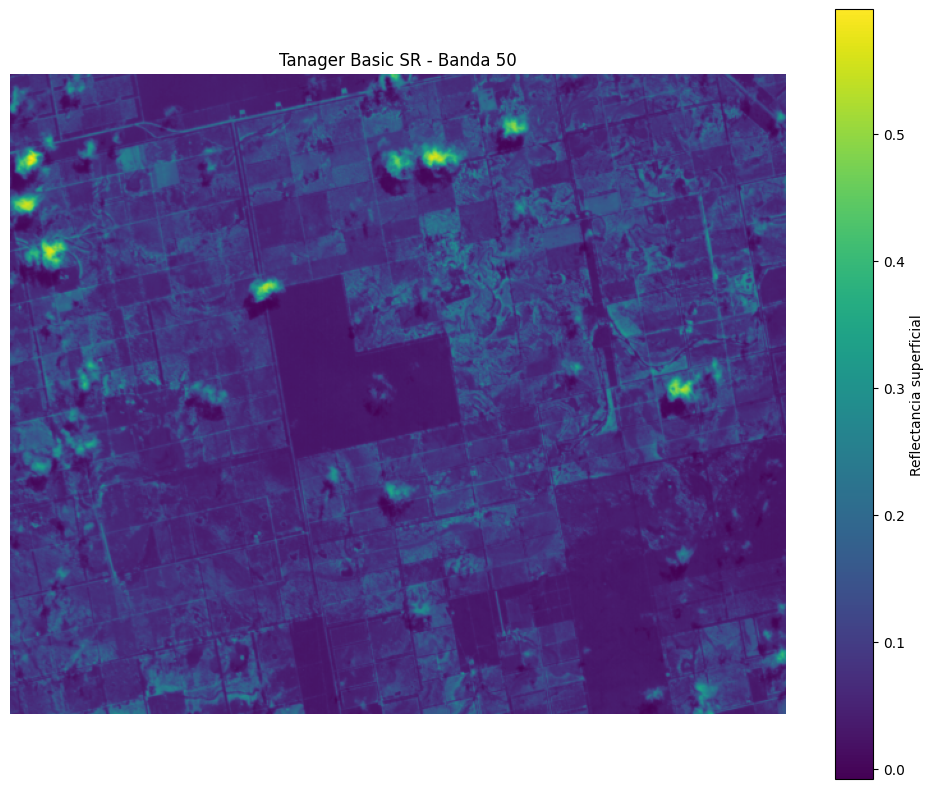

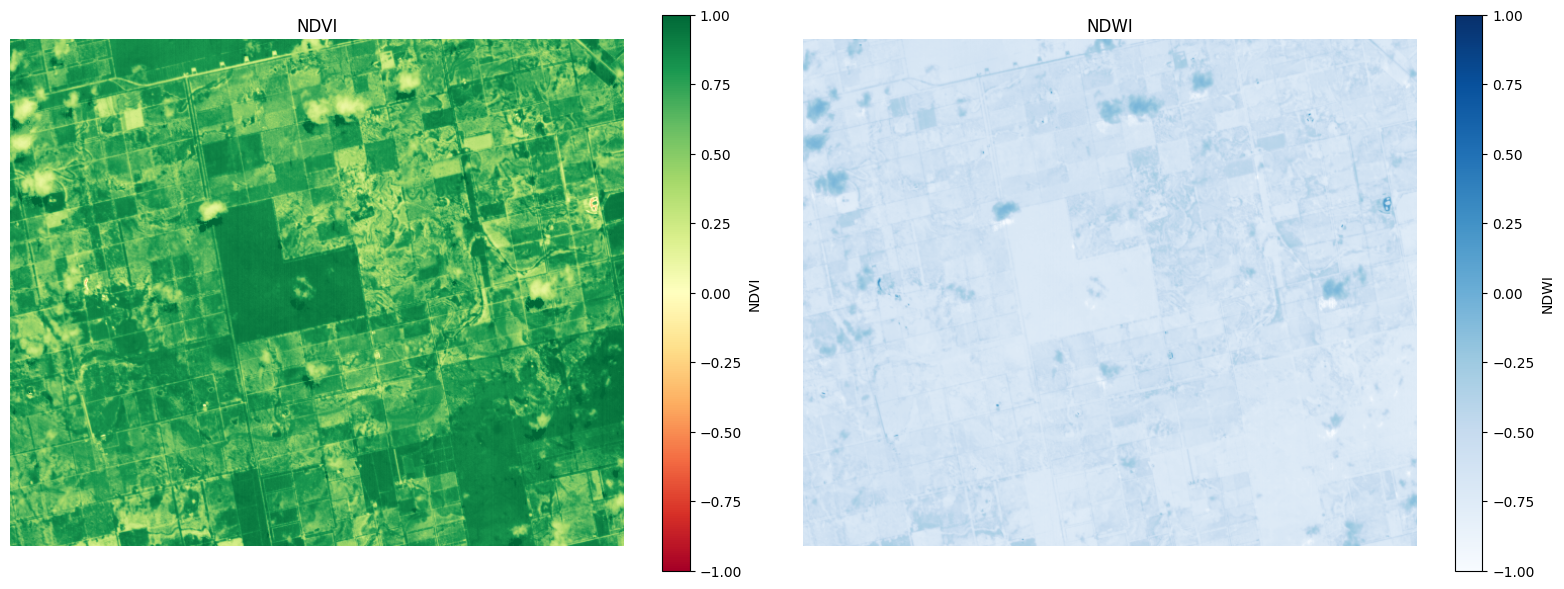

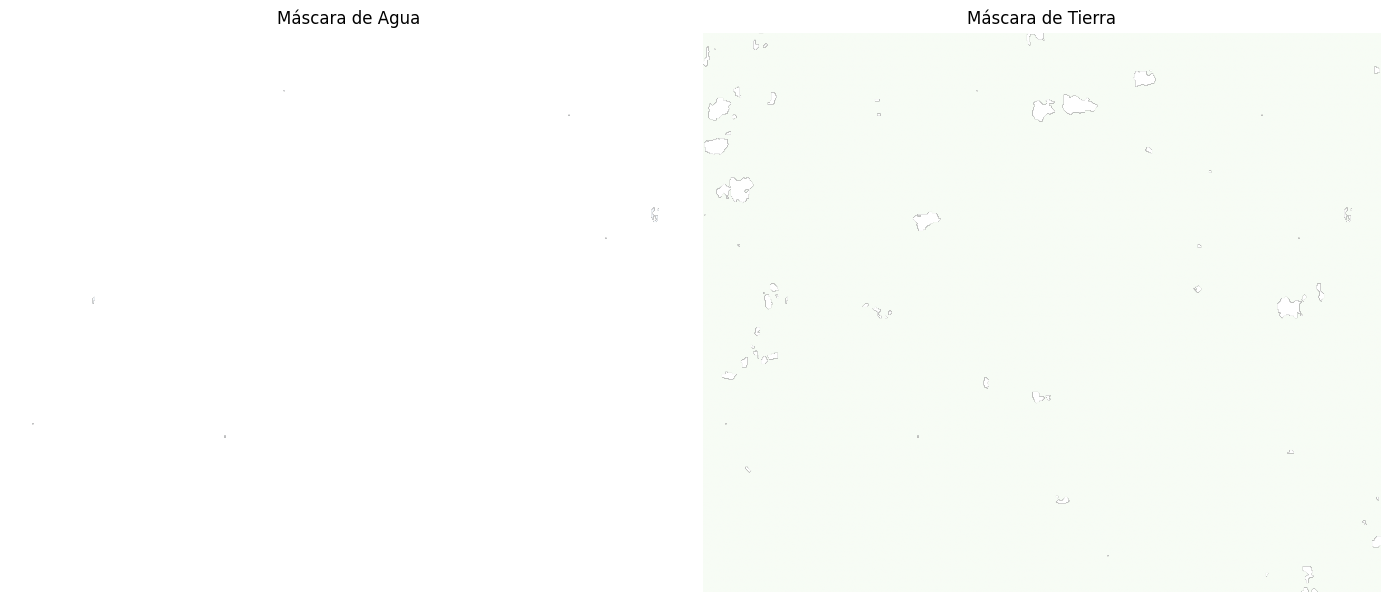

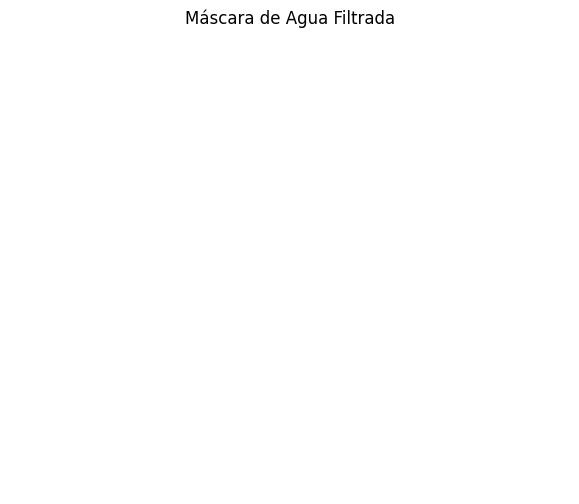

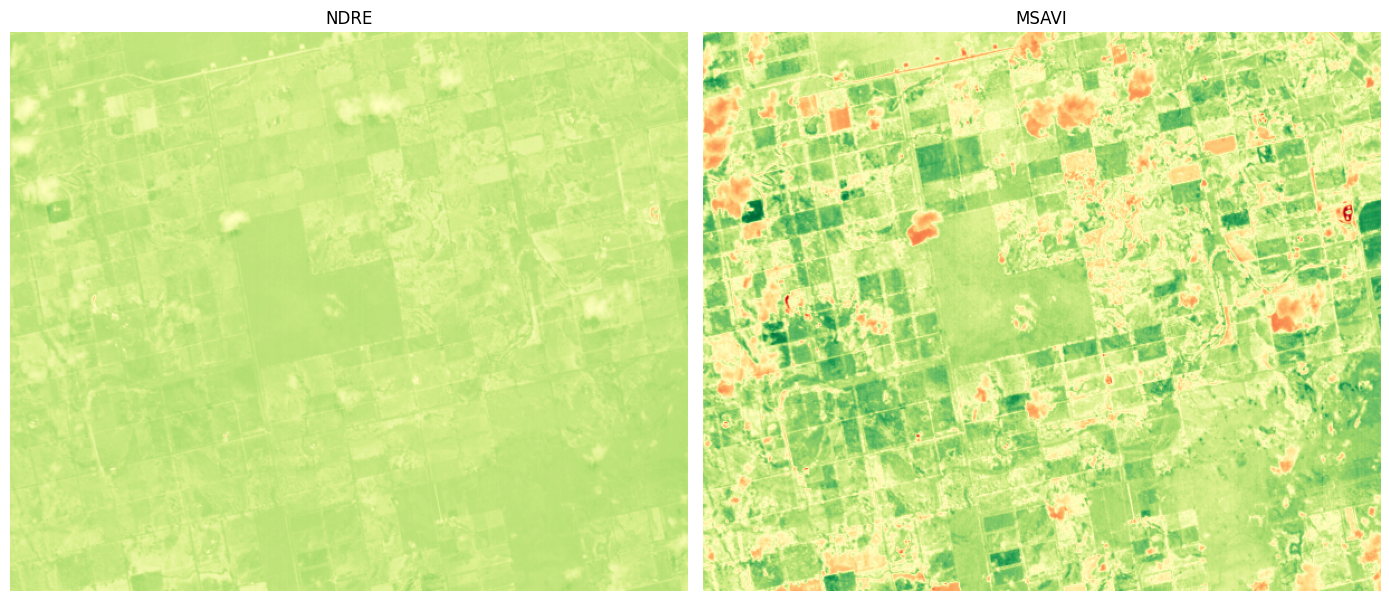

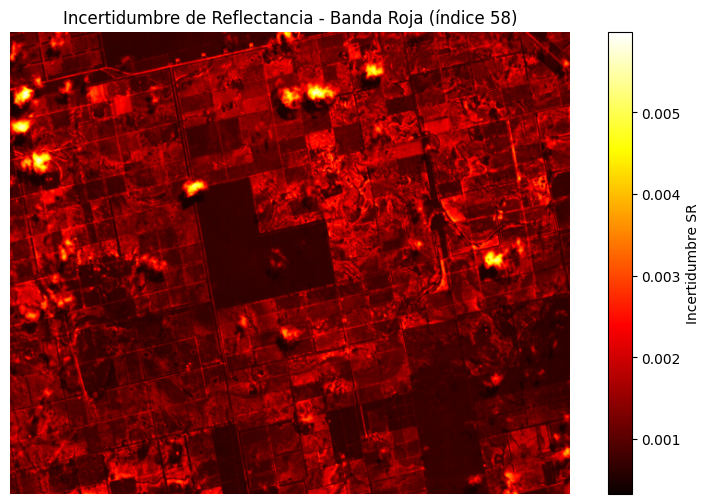

In [15]:
import matplotlib.pyplot as plt
import cv2

# --- 3a. Banda individual ---
band_index = 50
plt.figure(figsize=(10, 8))
plt.imshow(data[band_index, :, :], cmap='viridis')
plt.colorbar(label='Reflectancia superficial')
plt.title(f'Tanager Basic SR - Banda {band_index}')
plt.axis('off')
plt.tight_layout()
plt.show()

# --- 3b. NDVI y NDWI sin máscara ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im1 = axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('NDVI')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='NDVI')

im2 = axes[1].imshow(ndwi, cmap='Blues', vmin=-1, vmax=1)
axes[1].set_title('NDWI')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='NDWI')
plt.tight_layout()
plt.show()

# --- 3c. Máscaras agua / tierra (con máscara de nubes) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(water_mask, cmap='Blues')
axes[0].set_title("Máscara de Agua")
axes[1].imshow(land_mask, cmap='Greens')
axes[1].set_title("Máscara de Tierra")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# --- 3d. Máscara de agua filtrada con morfología ---
closing_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 40))
opening_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))

water_clean = cv2.morphologyEx(np.nan_to_num(water_mask), cv2.MORPH_CLOSE, closing_kernel)
water_clean = cv2.morphologyEx(water_clean, cv2.MORPH_OPEN, opening_kernel)
water_clean[water_clean == 0] = np.nan

plt.figure(figsize=(10, 6))
plt.imshow(water_clean, cmap='Blues')
plt.title("Máscara de Agua Filtrada")
plt.axis('off')
plt.show()

# --- 3e. NDRE y MSAVI ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(ndre, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title("NDRE")
axes[1].imshow(msavi, cmap='RdYlGn')
axes[1].set_title("MSAVI")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# --- 3f. Incertidumbre de reflectancia ---
plt.figure(figsize=(10, 6))
plt.imshow(uncertainty[red_idx, :, :], cmap='hot')
plt.colorbar(label='Incertidumbre SR')
plt.title(f'Incertidumbre de Reflectancia - Banda Roja (índice {red_idx})')
plt.axis('off')
plt.show()